# Intersectional bias analysis

**Goal:** Evaluating dataset viability to explore intersectional bias, finding elligible crossing between sensitive attributes and detecting baseline inbalances.

In [1]:
import sys 
import os

sys.path.append(os.path.abspath("../utils"))
from config import DATA_PATH, DATASETS

'''
Change dataset_to_evaluate to pick the correct dataset for your study
'''
dataset_to_evaluate = "MENTAL"
'''
Available options: AIDS, MENTAL, OBESITY, DIABETES
'''

processed_data_path = DATA_PATH / "processed"

In [2]:
dataset_config = DATASETS[dataset_to_evaluate]

DATASET_NAME = dataset_config["dataset_name"]

TARGET_COL = dataset_config["target_col"]
FAVORABLE_LABEL = dataset_config["favorable_label"]

# Sensitive attributes to evaluate
SENSITIVE_ATTRS = dataset_config["sensitive_attrs"]

MIN_SUBGROUP_COUNT = dataset_config["min_sub_count"]

CSV_FILE_NAME = dataset_config["processed_csv_file"]

### Visual configurations

In [3]:
import warnings
warnings. filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sab

from scipy import stats
from scipy.stats import chi2_contingency

LAB_PALETTE_SEQUENTIAL = [
    "#f0f9fa", # Ice white (Almost white, close to no correlation)
    "#b2ebf2", # Acqua
    "#3eccc4", # Teal (signs start to show up)
    "#1a659e", # Light Blue (moderate association)
    "#002a61"  # Navy Blue (critical association)
]

# global seaborn configurations

sab.set_theme(style="whitegrid")
sab.set_palette(LAB_PALETTE_SEQUENTIAL)

# custom heatmap based on palette
LAB_CMAP = LinearSegmentedColormap.from_list("LabGradient", LAB_PALETTE_SEQUENTIAL)

# LAB_PALETTE_20 for high density (20 colors)
LAB_PALETTE_CATEGORICAL = [
    # NAVY (Higher privilege/status)
    "#001b3d", # Navy Ultra Dark
    "#002a61", # Original Navy
    "#004b8d", # Medium Navy
    "#006cc2", # Shiny Navy
    
    # BLUE (Upper intermediate groups)
    "#134e7a", # Deep Blue
    "#1a659e", # Original Blue
    "#4d8fc1", # Steel Blue
    "#82b4dc", # Sky Blue
    
    # PURPLE (Transition/ Intersection zones)
    "#2e2c8f", # Deep Purple
    "#403eb1", # Purple Original
    "#6b69d6", # Medium Purple
    "#8e8cf2", # Lavender 
    
    # TEAL (Parity groups)
    "#168275", # Deep Teal
    "#1eaf9d", # Teal Original
    "#28d1bd", # Bright Teal
    "#5fe3d3", # Mint Teal
    
    # AQUA (Higher vulnerability)
    "#2fa39d", # Dark Aqua
    "#3eccc4", # Aqua Original
    "#66cbe1", # Sky Blue Original
    "#b3b1ff"  # Pale Lavender (lightest point)
]

sab.set_palette(LAB_PALETTE_CATEGORICAL)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Functions
The statistic method used for this evaluation is the Wilson Score Interval. It performs better for smaller instance numbers, avoiding noise-generated bias in samples.

In [4]:
def wilson_ci(k, n, z=1.96):
    '''Wilson Score Interval'''
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    spread = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return float(center - spread), float(center + spread)

def subgroup_label_stats(df, subgroup_col, target_col, favorable_label):
    '''Calculates favorable rate and WCI for each subgroup'''
    records = []
    for sg, grp in df.groupby(subgroup_col):
        n = len(grp)
        k = (grp[target_col] == favorable_label).sum()
        rate = k / n if n > 0 else np.nan
        lo, hi = wilson_ci(k, n)
        records.append({
            "subgroup": sg, "n": n, "favorable_n": int(k),
            "favorable_rate": rate, "IC_low": lo, "IC_high": hi
        })
    return pd.DataFrame(records).sort_values("subgroup").reset_index(drop=True)

def cramers_v(df, col1, col2):
    '''Cramer's V - determines how strongly two attributes are associated'''
    ct = pd.crosstab(df[col1], df[col2])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return float(np.sqrt(chi2 / (n * k))) if k > 0 else 0.0

print("✓ Done importing functions")

✓ Done importing functions


## Prerequisites
Each dataset evaluated here should run through its own pre-processing pipeline before using this analysis template. Some initial pre-processing is already done in `init_datasets.ipynb`, but some specifics are done in a separate notebook. Check `pre-processing.ipynb` and run the steps to the chosen dataset before proceeding.

## 1. Importing CSV file

In [5]:
# import csv file from processed data path:
df_pp = pd.read_csv(processed_data_path / f"{CSV_FILE_NAME}")
df_pp.head(5)

,age,self_employed,family_history,target,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,...,continent_europe,continent_north_america,continent_oceania,continent_south_america,leave_don't_know,leave_somewhat_difficult,leave_somewhat_easy,leave_very_difficult,leave_very_easy,age_group
0,46,1,1,0,1,1,1,0,1,0,...,0,1,0,0,0,0,0,0,1,35-50
1,36,1,1,0,1,1,0,0,1,0,...,1,0,0,0,0,0,1,0,0,35-50
2,29,0,1,1,0,1,1,1,0,0,...,0,1,0,0,0,1,0,0,0,19-34
3,31,1,0,0,1,1,0,0,0,0,...,0,1,0,0,0,1,0,0,0,19-34
4,46,0,0,1,1,1,1,1,0,0,...,0,1,0,0,1,0,0,0,0,35-50


## Sensitive Attributes Inventory

In [6]:
SECONDARY_ATTRS = dataset_config["secondary_attrs"]
ALL_ANALYSIS_ATTRS = SENSITIVE_ATTRS + SECONDARY_ATTRS

for attr in ALL_ANALYSIS_ATTRS:
    print(f"  {attr} (type: {df_pp[attr].dtype})")

    # Calculating frequencies and proportions
    counts = df_pp[attr].value_counts().sort_index()
    percents = df_pp[attr].value_counts(normalize=True).sort_index() * 100

    # Formatting view
    for val, count in counts.items():
        pct = percents[val]
        print(f"    {str(val):<30} n={count:>6,}  ({pct:>5.1f}%)")
    print()

# Checking for null values
null_check = df_pp[ALL_ANALYSIS_ATTRS].isnull().sum().sum()
if null_check == 0:
    print(f"✓ Quality Check: No missing values in analysis attributes.")
else:
    print(f"⚠ Warning: Found {null_check} missing values.")


  gender (type: int64)
    0                              n=   261  ( 21.2%)
    1                              n=   972  ( 78.8%)

  non_cis (type: int64)
    0                              n= 1,214  ( 98.5%)
    1                              n=    19  (  1.5%)

  continent_europe (type: int64)
    0                              n=   878  ( 71.2%)
    1                              n=   355  ( 28.8%)

  continent_africa (type: int64)
    0                              n= 1,226  ( 99.4%)
    1                              n=     7  (  0.6%)

  continent_asia (type: int64)
    0                              n= 1,210  ( 98.1%)
    1                              n=    23  (  1.9%)

  continent_eurasia (type: int64)
    0                              n= 1,230  ( 99.8%)
    1                              n=     3  (  0.2%)

  continent_north_america (type: int64)
    0                              n=   426  ( 34.5%)
    1                              n=   807  ( 65.5%)

  continent_oceania

## Feasibility of Crossed Subgroup Samples

  INTERSECTIONAL VIABILITY SCANNER — MENTAL HEALTH
  Minimum Threshold (n): 50
  Total combinations tested: 17

                Intersection Pair  Subgroups  Min N Viability (%)    Verdict
                 gender x non_cis          4      0         50.0% PARTIAL ⚠️
        gender x continent_europe          4     50        100.0%     FULL ✅
        gender x continent_africa          4      1         50.0% PARTIAL ⚠️
          gender x continent_asia          4      3         50.0% PARTIAL ⚠️
       gender x continent_eurasia          4      1         50.0% PARTIAL ⚠️
 gender x continent_north_america          4     61        100.0%     FULL ✅
       gender x continent_oceania          4      6         50.0% PARTIAL ⚠️
 gender x continent_south_america          4      0         50.0% PARTIAL ⚠️
               gender x age_group         10      0         40.0% CRITICAL ❌
       non_cis x continent_europe          4      7         50.0% PARTIAL ⚠️
       non_cis x continent_africa        

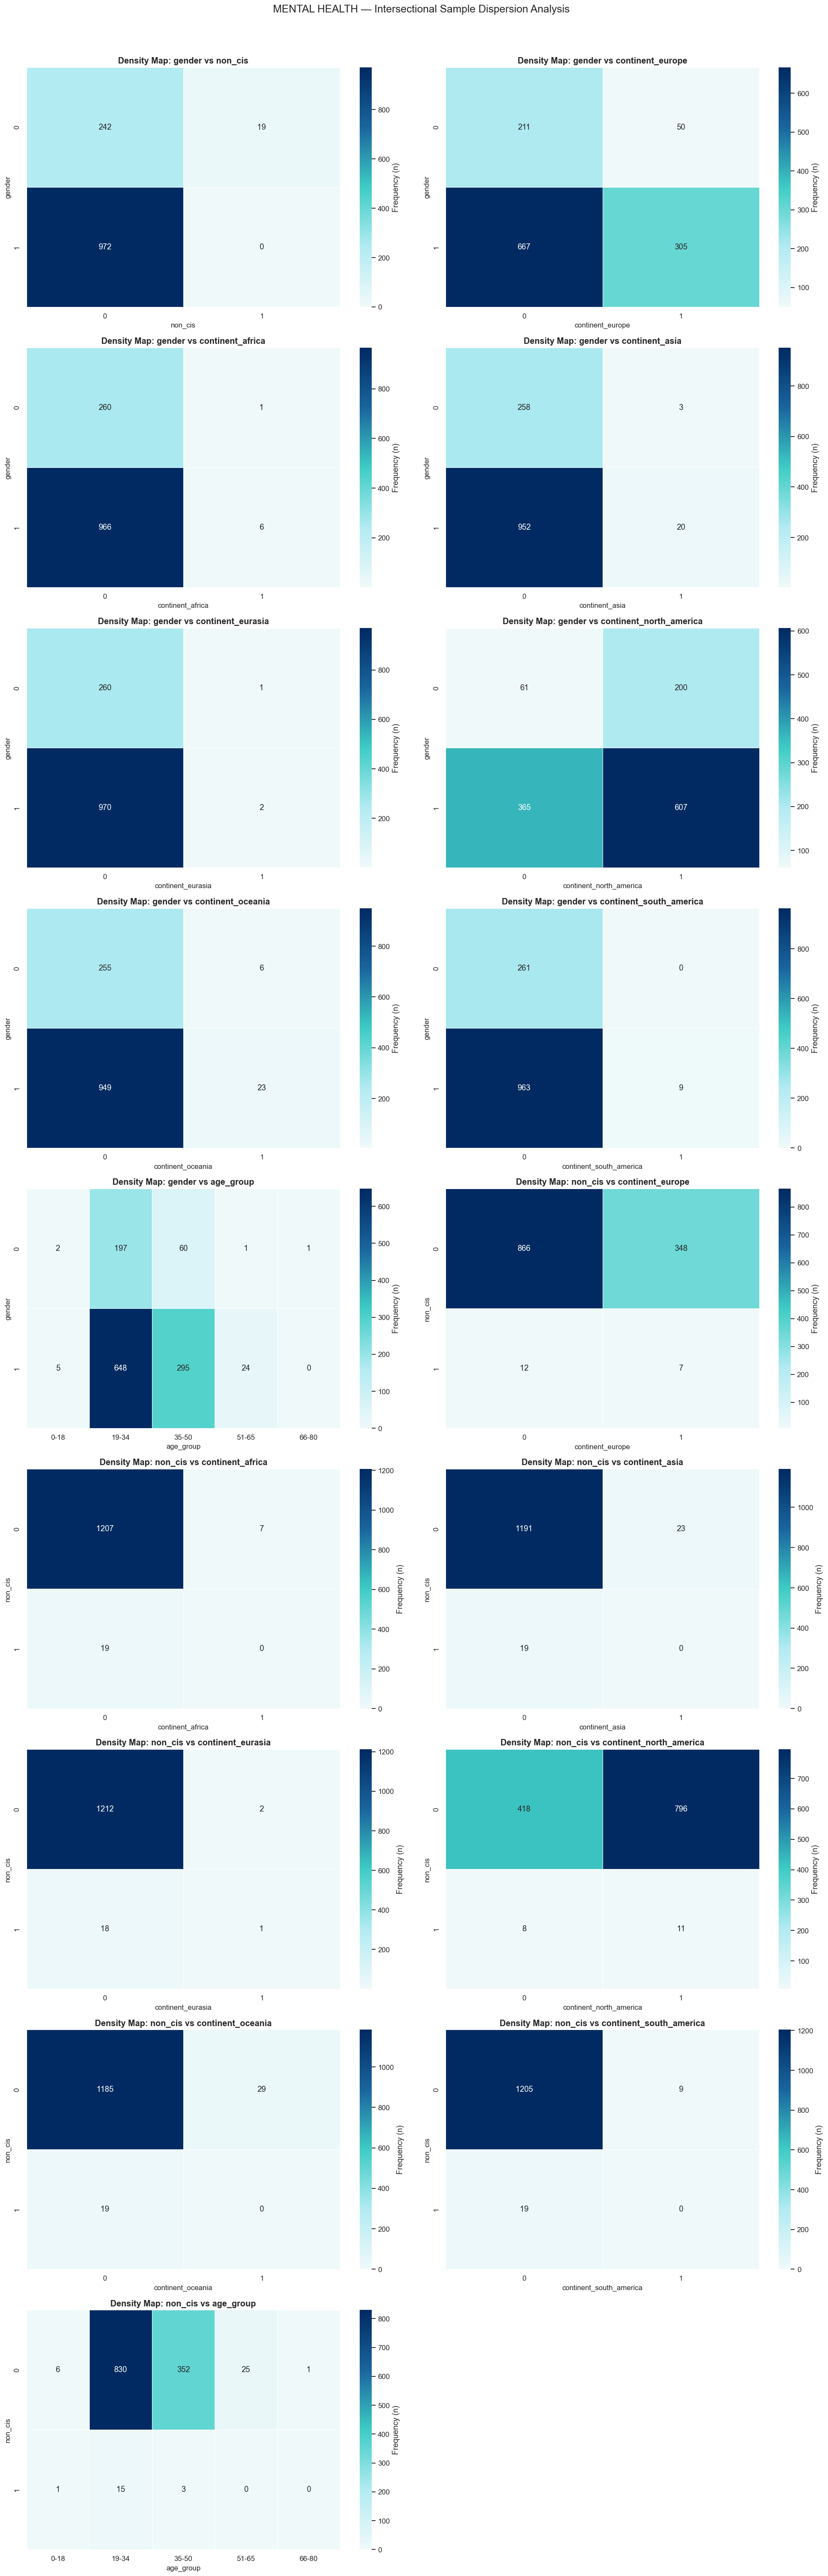

In [7]:
import itertools
import math

# Exhaustive pair generation
# Identity intersections (sensitive x sensitive)
sens_pairs = list(itertools.combinations(SENSITIVE_ATTRS, 2))

context_pairs = list(itertools.product(SENSITIVE_ATTRS, SECONDARY_ATTRS))

all_test_pairs = sens_pairs + context_pairs

print(f"{'='*75}")
print(f"  INTERSECTIONAL VIABILITY SCANNER — {DATASET_NAME}")
print(f"{'='*75}")
print(f"  Minimum Threshold (n): {MIN_SUBGROUP_COUNT}")
print(f"  Total combinations tested: {len(all_test_pairs)}\n")

viability_records = []
primary_intersections = [] # for viability == 100%
partial_intersections = [] # for viability >= 50%

for attr_a, attr_b in all_test_pairs:
    # Cross-tabulation
    ct = pd.crosstab(df_pp[attr_a], df_pp[attr_b])

    total_subgroups = ct.size
    min_n_found= int(ct.values.min())

    # Viability Criterion: cells meeting the threshold
    viable_cells = (ct >= MIN_SUBGROUP_COUNT).sum().sum()
    viability_pct = (viable_cells / total_subgroups) * 100

    # Verdict definition
    if viability_pct == 100:
        verdict = "FULL ✅"
        primary_intersections.append(f"{attr_a} x {attr_b}")
    elif viability_pct >= 50:
        verdict = "PARTIAL ⚠️"
        partial_intersections.append(f"{attr_a} x {attr_b}")
    else:
        verdict = "CRITICAL ❌"

    viability_records.append({
        "Intersection Pair": f"{attr_a} x {attr_b}",
        "Subgroups": total_subgroups,
        "Min N": min_n_found,
        "Viability (%)": f"{viability_pct:.1f}%",
        "Verdict": verdict
    })

# Display Summary Table
summary_df = pd.DataFrame(viability_records)
print(summary_df.to_string(index=False))

# Visualization
plot_pairs = all_test_pairs
n_plot = len(plot_pairs)
n_cols = 2
n_rows = math.ceil(n_plot / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()


for i, (attr_a, attr_b) in enumerate(plot_pairs):
    ct = pd.crosstab(df_pp[attr_a], df_pp[attr_b])
    
    # Heatmap using Lab Palette and Wilson-ready annotations
    sab.heatmap(ct, annot=True, fmt="d", cmap=LAB_CMAP, ax=axes[i], 
                linewidths=0.5, cbar_kws={"label": "Frequency (n)"})
    
    axes[i].set_title(f"Density Map: {attr_a} vs {attr_b}", fontsize=13, fontweight='bold')
    axes[i].set_xlabel(attr_b, fontsize=11)
    axes[i].set_ylabel(attr_a, fontsize=11)

# Clean empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"{DATASET_NAME} — Intersectional Sample Dispersion Analysis", fontsize=16, y=1.01)
plt.tight_layout()

# ── 4. Automatic Figure Saving ─────────────────────────────────────────────
file_name = f"{DATASET_NAME.replace(' ','_')}_block2_viability_analysis.png"
save_path = DATA_PATH / f"intersectional_analysis/{file_name}"
plt.savefig(save_path, bbox_inches="tight", dpi=300)

print(f"\n✓ Analysis complete. Figure saved at: {save_path}")
plt.show()

### Label By Subgroup

In [ ]:
# List of the two intersections that had a 100% score after scanning
PRIMARY_INTERSECTIONS = primary_intersections

if not PRIMARY_INTERSECTIONS:
    print("Skipping this step. No primary intersections found for this dataset.")
else:
    print(f"{'='*75}")
    print(f"  LABEL DISTRIBUTION ANALYSIS ({TARGET_COL} = {FAVORABLE_LABEL}) — {DATASET_NAME}")
    print(f"{'='*75}")

    global_rate = df_pp[TARGET_COL].mean()
    print(f"  Global Favorable Rate: {global_rate:.4f} ({global_rate:.2%})\n")

    for intersection in PRIMARY_INTERSECTIONS:
        attrs = intersection.split(' x ')
        col_name = '_x_'.join(attrs)

        df_pp[col_name] = df_pp[attrs].astype(str).apply(lambda row: ' × '.join(row.values), axis=1)

        label_stats = subgroup_label_stats(df_pp, col_name, TARGET_COL, FAVORABLE_LABEL)
    
        fig, ax = plt.subplots(figsize=(14,7))

        # Sorting by favorable rate to show the "Privilege scaling"
        label_stats = label_stats.sort_values("favorable_rate", ascending=False)

        x = range(len(label_stats))
        palette_cycle = [LAB_PALETTE_CATEGORICAL[i % len(LAB_PALETTE_CATEGORICAL)] for i in range(len(label_stats))]

        bars = ax.bar(x, label_stats["favorable_rate"], color=palette_cycle, edgecolor="white", zorder=2)
        ax.errorbar(
            x, label_stats["favorable_rate"],
            yerr=[label_stats["favorable_rate"] - label_stats["IC_low"],
            label_stats["IC_high"] - label_stats["favorable_rate"]],
            fmt="none", color="black", capsize=5, linewidth=1.5, zorder=3)

        # Global Reference
        ax.axhline(global_rate, color="#d9534f", linestyle="--", linewidth=1.5, 
            label=f"Global Rate ({global_rate:.2%})")

        # Academic formatting
        ax.set_xticks(x)
        ax.set_xticklabels(label_stats["subgroup"], rotation=45, ha="right", fontsize=10)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_title(f"Intersectional Outcome Gap: {intersection.title()}", fontsize=15, fontweight='bold', pad=20)
        ax.set_ylabel("Proportion with cid = 0", fontsize=12)
        ax.set_ylim(0, max(label_stats["IC_high"].max(), global_rate) * 1.15)
        ax.legend(loc='upper right')

        for i, (idx, row) in enumerate(label_stats.iterrows()):
            # N Label (under x axis)
            ax.text(i, -0.07, f"n={int(row['n']):,}", 
                ha="center", va="top", 
                fontsize=8.5, fontweight='bold', 
                color="#444444", 
                transform=ax.get_xaxis_transform())
        
            # PCT over error bar
            # We use row["IC_high"] + offset to avoid touching the line
            percentage = f"{row['favorable_rate']:.1%}"
            ax.text(i, row['IC_high'] + 0.01, percentage, 
                ha='center', va='bottom', 
                fontsize=9, fontweight='bold', 
                color=palette_cycle[i]) # Usa a mesma cor da barra para semântica
        
        plt.tight_layout()

        # Saving
        fig_name = f"{DATASET_NAME.replace(' ','_')}_block3_{col_name}_distribution.png"
        save_path = DATA_PATH / f"intersectional_analysis/{fig_name}"
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

        print(f"✓ Visualization generated and saved: {intersection}")
        plt.show()

In [ ]:
PARTIAL_INTERSECTIONS = partial_intersections

if not PARTIAL_INTERSECTIONS:
    print("Skipping this step. No partial intersections found for this dataset.")
else:
    print(f"{'='*75}")
    print(f"  PARTIAL INTERSECTION ANALYSIS cid = 0 — {DATASET_NAME}")
    print(f"  Note: Wilson CIs will be wider due to smaller sample sizes.")
    print(f"{'='*75}\n")

    global_rate = df_pp[TARGET_COL].mean()

    for intersection in PARTIAL_INTERSECTIONS:
        attrs = intersection.split(' x ')
        col_name = '_x_'.join(attrs)

        df_pp[col_name] = df_pp[attrs].astype(str).apply(lambda row: ' × '.join(row.values), axis=1)

        label_stats = subgroup_label_stats(df_pp, col_name, TARGET_COL, FAVORABLE_LABEL)

        fig, ax = plt.subplots(figsize=(15, 7))
        label_stats = label_stats.sort_values("favorable_rate", ascending=False)

        x = range(len(label_stats))
        palette_cycle = [LAB_PALETTE_CATEGORICAL[i % len(LAB_PALETTE_CATEGORICAL)] for i in range(len(label_stats))]

        bars = ax.bar(x, label_stats["favorable_rate"], color=palette_cycle, edgecolor="white", zorder=2, alpha=0.85)

        ax.errorbar(x, label_stats["favorable_rate"], 
                yerr=[label_stats["favorable_rate"] - label_stats["IC_low"], 
                      label_stats["IC_high"] - label_stats["favorable_rate"]],
                fmt="none", color="#2c3e50", capsize=5, linewidth=1.2, zorder=3)

        ax.axhline(global_rate, color="#d9534f", linestyle="--", linewidth=1.5, 
               label=f"Global Rate ({global_rate:.2%})")

        ax.set_xticks(x)
        ax.set_xticklabels(label_stats["subgroup"], rotation=45, ha="right", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_title(f"Partial Intersection Gap: {intersection.title()}", fontsize=15, fontweight='bold', pad=20)
        ax.set_ylabel("Proportion with cid = 0", fontsize=12)

        ax.set_ylim(0, 1.1) 
        ax.legend(loc='upper right')

        for i, (idx, row) in enumerate(label_stats.iterrows()):

            n_color = "#d9534f" if row['n'] < MIN_SUBGROUP_COUNT else "#555555"
            n_weight = 'bold' if row['n'] < MIN_SUBGROUP_COUNT else 'normal'

            ax.text(i, -0.07, f"n={int(row['n']):,}", 
                ha="center", va="top", 
                fontsize=8, color=n_color, fontweight=n_weight,
                transform=ax.get_xaxis_transform())

            percentage = f"{row['favorable_rate']:.1%}"
            ax.text(i, row['IC_high'] + 0.02, percentage, 
                ha='center', va='bottom', 
                fontsize=9, fontweight='bold', 
                color=palette_cycle[i % len(palette_cycle)])

        plt.tight_layout()

        fig_name = f"{DATASET_NAME.replace(' ','_')}_block3_PARTIAL_{col_name}.png"
        save_path = DATA_PATH / f"intersectional_analysis/{fig_name}"
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        
        print(f"✓ Visualization generated and saved: {intersection}")
        plt.show()
    

# Justice Gerrymandering

Comparing disparity observed in marginal analysis (one attribute at once) with intersectional disparity

**Hidden positive bias** = marginal analysis overestimates real disparity

In [ ]:
print(f"{'='*85}")
print(f"  JUSTICE GERRYMANDERING AUDIT — {DATASET_NAME}")
print(f"  Measuring the 'Hidden Bias' surplus in Intersectional Subgroups")
print(f"{'='*85}\n")

# Complete attribute list for auditing
ALL_AUDIT_ATTRS = SENSITIVE_ATTRS + SECONDARY_ATTRS

def get_marginal_gap(df, attr):
    """Calculates disparity for a single attribute"""
    rates = df.groupby(attr)[TARGET_COL].mean()
    return float(rates.max() - rates.min()), rates

# Calculating marginal gaps
marginal_data = {attr: get_marginal_gap(df_pp, attr) for attr in ALL_AUDIT_ATTRS}

# 3. Intersection audit
audit_pairs = list(itertools.combinations(set(ALL_AUDIT_ATTRS), 2))

audit_records = []

for attr_a, attr_b in audit_pairs:
    col_inter = f"{attr_a}_x_{attr_b}"
    if col_inter not in df_pp.columns:
        df_pp[col_inter] = df_pp[[attr_a, attr_b]].astype(str).apply(lambda row: " x ".join(row.values), axis=1)

    # Individual gaps (what would be originally seen)
    gap_a = marginal_data[attr_a][0]
    gap_b = marginal_data[attr_b][0]
    max_marginal = max(gap_a, gap_b)

    # Intersectional gap (real, generated from crossing data)
    stats_inter = subgroup_label_stats(df_pp, col_inter, TARGET_COL, FAVORABLE_LABEL)
    gap_inter = float(stats_inter["favorable_rate"].max() - stats_inter["favorable_rate"].min())

    h_bias = gap_inter - max_marginal

    audit_records.append({
        "Intersection Pair": f"{attr_a} x {attr_b}",
        "Indiv. Gap A": gap_a,
        "Indiv. Gap B": gap_b,
        "Expected Gap (Max Marginal)": max_marginal,
        "Real Gap (Intersectional)": gap_inter,
        "Hidden Bias (Surplus)": h_bias,
        "Audit Veredict": "⚠️ GERRYMANDERING" if h_bias > 0.01 else "✅ CAPTURED"
    })

# Evidence Table view
audit_df = pd.DataFrame(audit_records)
print("TABLE: EVIDENCE OF INTERSECTIONAL INVISIBILITY\n")
print("This table evaluates 'Hidden Bias' by contrasting the maximum marginal disparity (Expected Gap) against the real intersectional disparity (Real Gap).")
print("A positive surplus confirms that intersectional groups face cumulative harms that remain invisible to single-axis fairness metrics.\n")

print("-" * 30)
print("GLOSSARY & INTERPRETATION:")
print("Expected Gap: The maximum disparity found between the individual attributes that compose the pair (max[Gap_A, Gap_B]).")
print("Real Gap: The actual difference between the most privileged and most vulnerable subgroups within the intersection.")
print("Hidden Bias (Surplus): The 'invisible' portion of disparity. A value > 0 indicates that marginal analysis fails to see the full extent of intersectional harm.")
print("-" * 30)

styled_table = audit_df.style.format({
    "Indiv. Gap A": "{:.2%}", "Indiv. Gap B": "{:.2%}", 
    "Expected Gap (Max Marginal)": "{:.2%}", 
    "Real Gap (Intersectional)": "{:.2%}", 
    "Hidden Bias (Surplus)": "{:+.2%}"
}).apply(lambda x: ['background-color: #ffcccc; font-weight: bold' if v == "⚠️ GERRYMANDERING" else '' for v in x], subset=['Audit Veredict'])

display(styled_table)

# Global audit view (comparing all pairs)
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Graph A - comparing Gaps for all pairs
x_audit = np.arange(len(audit_df))
width = 0.35

# Bar plot - side by side: expected x real
bars1 = axes[0].bar(x_audit - width/2, audit_df["Expected Gap (Max Marginal)"], 
                    width, label='Expected Gap (Marginal)', color=LAB_PALETTE_CATEGORICAL[0], alpha=0.7)
bars2 = axes[0].bar(x_audit + width/2, audit_df["Real Gap (Intersectional)"], 
                    width, label='Real Gap (Intersectional)', color=LAB_PALETTE_CATEGORICAL[1])

# Adding percentage labels on top
for bar in bars2:
    height = bar.get_height()
    axes[0].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Graph A Visuals
axes[0].set_xticks(x_audit)
axes[0].set_xticklabels(audit_df["Intersection Pair"], rotation=15, ha="right")
axes[0].set_title("Gap Audit: Single-Axis vs. Intersectional Disparity", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Gap Amplitude (%)")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Graph B - Marginal Distribution of Success (Base attributes)
top_attrs = ["gender", "homo", "race"]
x_pos = np.arange(len(top_attrs))
for i, attr in enumerate(top_attrs):
    rates = marginal_data[attr][1]
    for j, (val, rate) in enumerate(rates.items()):
        offset = (j - len(rates)/2 + 0.5) * 0.15
        axes[1].bar(i + offset, rate, width=0.12, color=LAB_PALETTE_CATEGORICAL[j % len(LAB_PALETTE_CATEGORICAL)], 
                    edgecolor="white", alpha=0.9)

axes[1].axhline(global_rate, color="#d9534f", linestyle="--", alpha=0.8, label=f"Global Rate ({global_rate:.1%})")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([a.replace('_group','').capitalize() for a in top_attrs])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title("Reference: Marginal Success Rates by Category", fontsize=13, fontweight='bold')

plt.suptitle(f"{DATASET_NAME} — Full Fairness Audit Results", fontsize=16, y=1.02)
plt.tight_layout()

fig_name = f"{DATASET_NAME.replace(' ','_')}_block4_full_audit.png"
save_path = DATA_PATH / f"intersectional_analysis/{fig_name}"
plt.savefig(save_path, bbox_inches="tight", dpi=300)
plt.show()

## Correlating Sensitive attributes and Features

Mathematical Formulation

Cramér's V is derived from the Pearson's Chi-squared (χ2) test.

The calculation follows these steps:

    Calculate the Chi-squared Statistic (χ2): We compare the observed frequencies (O) against the expected frequencies (E) under the assumption of independence.

χ2=∑(Oi,j−Ei,j)2Ei,j

    Compute Cramér's V: The statistic is normalized to account for the sample size (n) and the dimensions of the contingency table.

V=√χ2/nmin(k−1,r−1)

Where:

n: Total number of samples.

k: Number of columns in the contingency table.

r: Number of rows in the contingency table.

In [ ]:
print(f"{'='*75}")
print(f"  PROXY ANALYSIS: SENSITIVE ATTRS vs. FEATURES — {DATASET_NAME}")
print(f"{'='*75}\n")

# 1. Identify features to evaluate (Excluding target and temporary columns)
feature_cols = [c for c in df_pp.columns 
                if c not in SENSITIVE_ATTRS + [TARGET_COL] 
                and "_x_" not in c]

# Filter for categorical or Low-cardinality features
cat_features = [c for c in feature_cols 
                if df_pp[c].dtype == "object" or df_pp[c].dtype.name == 'category' or df_pp[c].nunique() <= 15]

print(f"    Evaluate {len(cat_features)} potential proxy features.")

records = []
for attr in SENSITIVE_ATTRS:
    for feat in cat_features:
        try:
            # Calculate Cramér's V
            v = cramers_v(df_pp.dropna(subset=[attr, feat]), attr, feat)
            records.append({
                "Sensitive Attribute": attr,
                "Predictor Feature": feat,
                "Cramér's V": v
            })
        except Exception as e:
            continue

cv_df = pd.DataFrame(records)

# Top Proxies Summary
print("\n   Top Statistical Proxies (Cramér's V > 0.30 indicate strong association):")
if not cv_df.empty:
    high_proxies = cv_df[cv_df["Cramér's V"] > 0.30].sort_values("Cramér's V", ascending=False)
    if not high_proxies.empty:
        print(high_proxies.to_string(index=False))
    else:
        print("  No strong proxies detected (V > 0.30).")
else:
    print("  No data recorded for proxies.")

# 3. Visualization: Correlation Heatmap
if not cv_df.empty:
    pivot_cv = cv_df.pivot(index="Predictor Feature", columns="Sensitive Attribute", values="Cramér's V")

    plt.figure(figsize=(10, 8))
    sab.heatmap(pivot_cv, annot=True, fmt=".3f", cmap=LAB_CMAP, 
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Cramér's V"})

    plt.title(f"Proxy Detection: Feature Association with Sensitive Attributes", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Sensitive Attribute", fontsize=11)
    plt.ylabel("Model Feature", fontsize=11)

fig_name = f"{DATASET_NAME.replace(' ','_')}_block5_proxy_analysis.png"
save_path = DATA_PATH / f"intersectional_analysis/{fig_name}"
plt.savefig(save_path, bbox_inches="tight", dpi=300)

print(f"\n✓ Proxy analysis complete. Heatmap saved at: {save_path}")
plt.show()

## Data-Driven Intersectional Ranking
The ranking system establishes optimization priority through a Priority Score, allowing the dataset to reveal where bias is most severe without subjective researcher interference.

Priority Score=(Hidden Bias×0.7)+(Real Gap×0.3)

Calculation Criteria:

    Hidden Bias (70% Weight): The primary metric. It identifies the Justice Gerrymandering phenomenon, prioritizing intersections where bias is "invisible" to traditional (single-axis) metrics.
    Real Gap (30% Weight): Evaluates the absolute severity of exclusion by measuring the total distance between the most and least privileged subgroups.
    Viability Filter (Hard Constraint): Before scoring, the system validates whether all subgroups meet the minimum sample size (n). Inviable intersections are discarded or moved to the bottom of the ranking to prevent statistically unstable conclusions.


In [ ]:
# Resolve Case-sensitivity
audit_df['Merge_Key'] = audit_df['Intersection Pair'].str.lower().str.replace(" ", "").str.strip().astype(str)
summary_df['Merge_Key'] = summary_df['Intersection Pair'].str.lower().str.replace(" ", "").str.strip().astype(str)

decision_matrix = pd.merge(
    audit_df, 
    summary_df[['Merge_Key', 'Min N']], 
    on='Merge_Key'
).drop(columns=['Merge_Key'])

decision_matrix['Priority_Score'] = (
    (decision_matrix['Hidden Bias (Surplus)'] * 0.7) + 
    (decision_matrix['Real Gap (Intersectional)'] * 0.3)
)

# Feasibility filter
decision_matrix['Is_Viable'] = decision_matrix['Min N'] >= MIN_SUBGROUP_COUNT

# Ranking intersections
ranked_audit = decision_matrix.sort_values(by=['Is_Viable', 'Priority_Score'], ascending=False)

# Global Ranking view
print(f"{'═'*85}")
print(f"  GLOBAL INTERSECTIONAL AUDIT — {DATASET_NAME}")
print(f"  Ranking candidates for Fairness Optimization based on Objective Criteria")
print(f"{'═'*85}\n")

def highlight_viability(val):
    color = 'lightgreen' if val >= MIN_SUBGROUP_COUNT else '#ffcccc'
    return f'background-color: {color}'

display(ranked_audit.style.format({
    "Indiv. Gap A": "{:.2%}", "Indiv. Gap B": "{:.2%}", 
    "Expected Gap (Max Marginal)": "{:.2%}", "Real Gap (Intersectional)": "{:.2%}", 
    "Hidden Bias (Surplus)": "{:+.2%}", "Priority_Score": "{:.4f}"
}).map(highlight_viability, subset=['Min N']))

# "Best Candidate" verdict
viable_candidates = ranked_audit[ranked_audit['Is_Viable']]

if not viable_candidates.empty:
    best_candidate = viable_candidates.iloc[0]
    print(f"\n🏆 PRIMARY CANDIDATE FOR OPTIMIZATION: {best_candidate['Intersection Pair']}")
    print(f"  - This pair shows the highest combination of 'Hidden Bias' and total disparity.")
    print(f"  - All subgroups meet the minimum density (Min N = {best_candidate['Min N']}).")
else:
    print("\n❌ NO VIABLE CANDIDATES FOUND")
    print(f"  - All intersection pairs have subgroups with N < {MIN_SUBGROUP_COUNT}.")
    print("  - Consider reducing MIN_SUBGROUP_COUNT or reviewing your data filters.")

try:
    top_proxies = cv_df[cv_df["Cramér's V"] > 0.30].sort_values("Cramér's V", ascending=False)
    if not top_proxies.empty:
        print(f"\n⚠️ PROXY RISK DETECTED:")
        for _, row in top_proxies.head(2).iterrows():
            print(f"  - '{row['Predictor Feature']}' leaks information about '{row['Sensitive Attribute']}' (V={row['Cramér\'s V']:.3f})")
except:
    pass

print(f"\n{'═'*85}")

## Sanity Check

Last dataset validation

In [ ]:
# Checks if dataset is not emptied by filters
assert len(df_pp) > 0

# Checks absence of null data in columns
cols_to_check = SENSITIVE_ATTRS + [TARGET_COL]
assert df_pp[cols_to_check].isnull().sum().sum() == 0, f"ERROR: null values detected in crucial columns {cols_to_check}"

# Target column Validation
assert df_pp[TARGET_COL].nunique() == 2, f"ERROR: target variable {TARGET_COL} does not have exactly 2 classes"

print(f"✅ All generic integrity checks have passed.")
print(f"📊 Dataset ended with {len(df_pp):,} samples and ready for optimization.")

## Pre-training intersectional bias evaluation (table 1 adaptation)
The Class Imbalance Ratio (CI Ratio) measures the overall proportion between the majority and minority classes of the target variable, highlighting the general data distribution. Conversely, the Intersectional Disparate Impact (DI Pre-train) focuses on fairness assessment; it is calculated by dividing the favorable outcome rate of the most unprivileged subgroup by the rate of the most privileged subgroup within a specific intersection (such as sex and education). In the fairness literature, DI values below 0.80 violate the "Four-Fifths Rule," statistically proving that the historical baseline data carries severe discriminatory bias and necessitates multiobjective mitigation.

In [ ]:
print("Calculating metrics of pre-training intersectional bias...\n")

# Global dataset stats
N_total = len(df_pp)
class_counts = df_pp[TARGET_COL].value_counts(normalize=True) * 100
maj_class = class_counts.max()
min_class = class_counts.min()

ci_ratio = maj_class / min_class
class_dist_str = f"{maj_class:.1f} / {min_class:.1f}"

# Showing global metrics as header
print(f"📊 DATASET OVERVIEW: {DATASET_NAME}")
print(f"   Target Attribute : {TARGET_COL}")
print(f"   Total Instances  : {N_total:,}")
print(f"   Class Dist (%)   : {class_dist_str}")
print(f"   CI Ratio         : {ci_ratio:.2f}")
print("-" * 55)

# Define intersections to be reported
ALL_INTERSECTIONS = PRIMARY_INTERSECTIONS + PARTIAL_INTERSECTIONS
intersections_to_report = [item.replace(' ', '_') for item in ALL_INTERSECTIONS]

records = []

# Intersectional DI Loop Calculation
for inter in intersections_to_report:
    if inter in df_pp.columns:
        subgroup_rates = df_pp.groupby(inter)[TARGET_COL].apply(lambda x: (x == FAVORABLE_LABEL).mean())
        
        max_rate = subgroup_rates.max()
        min_rate = subgroup_rates.min()
        
        priv_group = subgroup_rates.idxmax()
        unpriv_group = subgroup_rates.idxmin()
        
        di_pre_train = min_rate / max_rate if max_rate > 0 else 0.0
        
        records.append({
            "Intersection Pair": inter.replace("_", " ").title(),
            "Most Privileged": priv_group,
            "Most Unprivileged": unpriv_group,
            "DI Pre-train": round(di_pre_train, 2)
        })

# Formatting Compact Table
pre_train_bias_table = pd.DataFrame(records)

print(f"\n{'='*80}")
print(" Table 1. Intersectional Pre-training Bias Evaluation.")
print(f"{'='*80}")

def highlight_di(val):
    if isinstance(val, float) and val < 0.80:
        return 'color: #d9534f; font-weight: bold'
    return ''

display(pre_train_bias_table.style.format({
    "DI Pre-train": "{:.2f}"
}).map(highlight_di, subset=['DI Pre-train']).hide(axis='index'))